In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
df = pd.read_csv(url)
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
715,2014,MAZDA,MAZDA6,MID-SIZE,2.5,4,AS6,X,8.8,6.2,7.6,37,175
372,2014,FORD,F150 4X4,PICKUP TRUCK - STANDARD,3.5,6,A6,X,15.9,11.3,13.8,20,317
315,2014,DODGE,DART,MID-SIZE,2.4,4,A6,X,10.1,6.8,8.6,33,198
130,2014,BMW,X5 xDRIVE35i,SUV - STANDARD,3.0,6,A8,Z,12.9,8.8,11.1,25,255
997,2014,TOYOTA,TACOMA,PICKUP TRUCK - SMALL,2.7,4,M5,X,11.3,8.9,10.2,28,235


In [4]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


Data is Complete, however we see ModelYear has 0 SD means its irrelevant here.
Also we wont need city and highway fuel consumption since we have combined already, and also fuel consumption in MPG is just different unit so we also wont need it.

In [6]:
features = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
features.sample(5)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
809,1.6,4,8.5,196
972,1.8,4,7.7,177
173,6.2,8,16.6,382
50,5.2,10,15.4,354
615,1.6,4,7.6,175


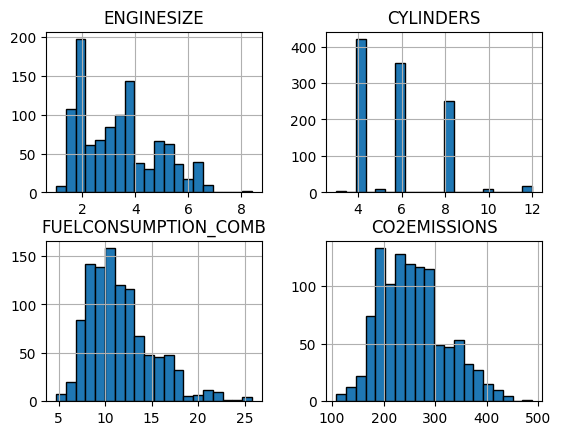

In [8]:
viz = features[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_COMB', 'CO2EMISSIONS']]
viz.hist(bins=20, edgecolor='black')
plt.show()

- Engine Size is b/w 2 to 4
- Cylinders are 4,6,8
- Fuel Consumption is mostly between 7 to 13
- CO2 emmissions are between 190 to 300

Since we have to find how each features contribute to CO2 Emmissions, plot relation between each of them against it

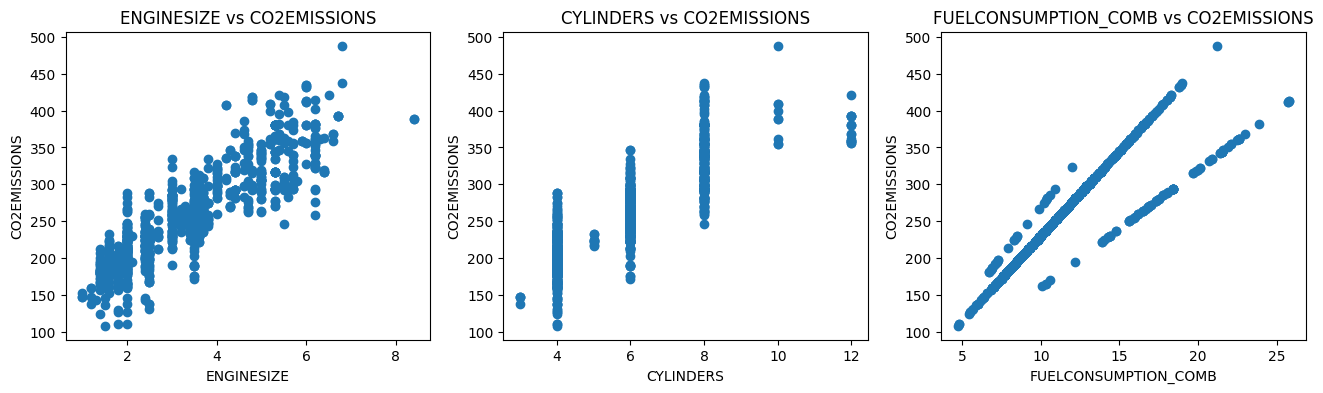

In [24]:
cols = features.drop(columns=['CO2EMISSIONS']).columns
target='CO2EMISSIONS'
fig, axes = plt.subplots(1,3,figsize=(16,4))
for ax,x in zip(axes,cols):
    ax.scatter(x=x, y=target, data=features)
    ax.set_xlabel(x)
    ax.set_ylabel(target)
    ax.set_title(f"{x} vs {target}")

- As Engine Size Increase, CO2 Emissions increase too.
- Same can be said about cylinders but huge overlap between each of them so its weak.
- Fuel Consunmption is perfectly linear (its just chemistry bcz combustion of fuel emits CO2)

In [27]:
features.corr()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.819482,0.874154
CYLINDERS,0.934011,1.000000,0.776788,0.849685
FUELCONSUMPTION_COMB,0.819482,0.776788,1.000000,0.892129
CO2EMISSIONS,0.874154,0.849685,0.892129,1.000000


- Just like we said, Fuel Consumption is strogest indicator of CO2 Emmissions with 89% correlation
- Obviously More cylinder mean bigger engine size but its not useful here


In [33]:
x = features[['FUELCONSUMPTION_COMB']]
y = features['CO2EMISSIONS']

In [34]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42)
type(x_train)

pandas.DataFrame

In [35]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
print('Cofficient = ', model.coef_[0])
print('Intercept = ', model.intercept_)

Cofficient =  16.156306155583543
Intercept =  69.20775487298732


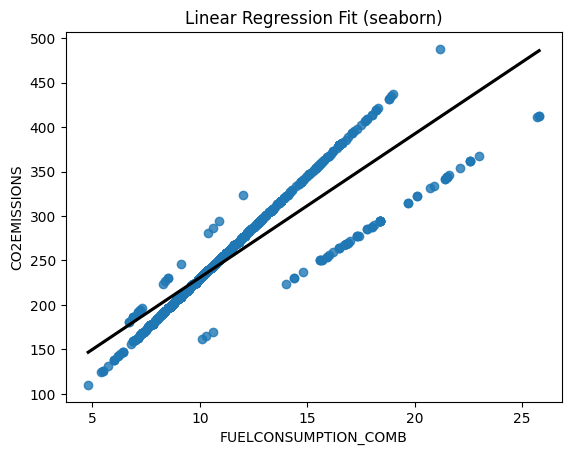

In [36]:
import seaborn as sns
sns.regplot(x=x_train, y=y_train, ci=None, line_kws={'color':'black'})
plt.xlabel('FUELCONSUMPTION_COMB')
plt.ylabel('CO2EMISSIONS')
plt.title('Linear Regression Fit (seaborn)')
plt.show()

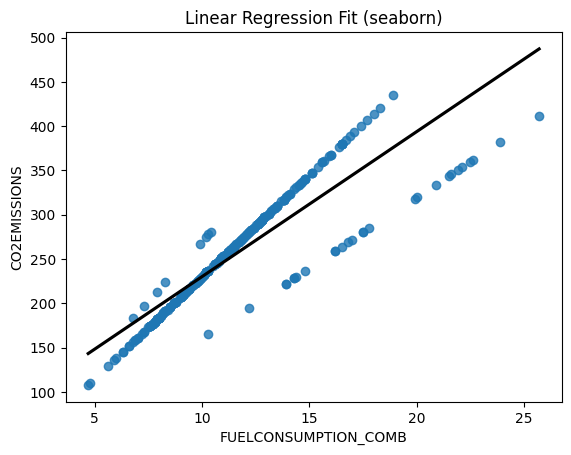

In [40]:
y_pred = model.predict(x_test)
sns.regplot(x=x_test, y=y_test, ci=None, line_kws={'color':'black'})
plt.xlabel('FUELCONSUMPTION_COMB')
plt.ylabel('CO2EMISSIONS')
plt.title('Linear Regression Fit (seaborn)')
plt.show()

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Mean absolute error: ", mean_absolute_error(y_test, y_pred))
print("Mean squared error: ", mean_squared_error(y_test, y_pred))
print("Root mean squared error: ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2-score: ", r2_score(y_test, y_pred))

Mean absolute error:  20.762901664763724
Mean squared error:  806.347573270993
Root mean squared error:  28.396259846518397
R2-score:  0.8000872270086814


Now lets practice multiple LR

In [47]:
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
340,2014,FIAT,500L TURBO,STATION WAGON - SMALL,1.4,4,AM6,X,10.0,7.2,8.7,32,200
416,2014,FORD,MUSTANG,SUBCOMPACT,3.7,6,A6,X,12.1,7.8,10.2,28,235
156,2014,CADILLAC,ATS,COMPACT,2.0,4,AS6,Z,11.3,7.5,9.6,29,221
988,2014,TOYOTA,PRIUS c,COMPACT,1.5,4,AV,X,4.6,4.9,4.7,60,108
252,2014,CHEVROLET,SONIC 5,MID-SIZE,1.4,4,M6,X,8.5,6.2,7.5,38,172


In [55]:
features = df.select_dtypes(exclude=['object','str'])
features.drop(columns=['MODELYEAR'], inplace=True)
features.dtypes

ENGINESIZE                  float64
CYLINDERS                     int64
FUELCONSUMPTION_CITY        float64
FUELCONSUMPTION_HWY         float64
FUELCONSUMPTION_COMB        float64
FUELCONSUMPTION_COMB_MPG      int64
CO2EMISSIONS                  int64
dtype: object

In [57]:
features.corr()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
CYLINDERS,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
FUELCONSUMPTION_CITY,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
FUELCONSUMPTION_HWY,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
FUELCONSUMPTION_COMB,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
FUELCONSUMPTION_COMB_MPG,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
CO2EMISSIONS,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


- Fuel Consumption Combined (MPG) is highest correlated function sp its our strongest indicator
- We can drop other Fuel Consumption Columns
- Cylinder is highly lowest correlation one so we can drop it

In [59]:
features.drop(columns=['CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB'], inplace=True)
features.corr()

,ENGINESIZE,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
ENGINESIZE,1.000000,-0.808554,0.874154
FUELCONSUMPTION_COMB_MPG,-0.808554,1.000000,-0.906394
CO2EMISSIONS,0.874154,-0.906394,1.000000


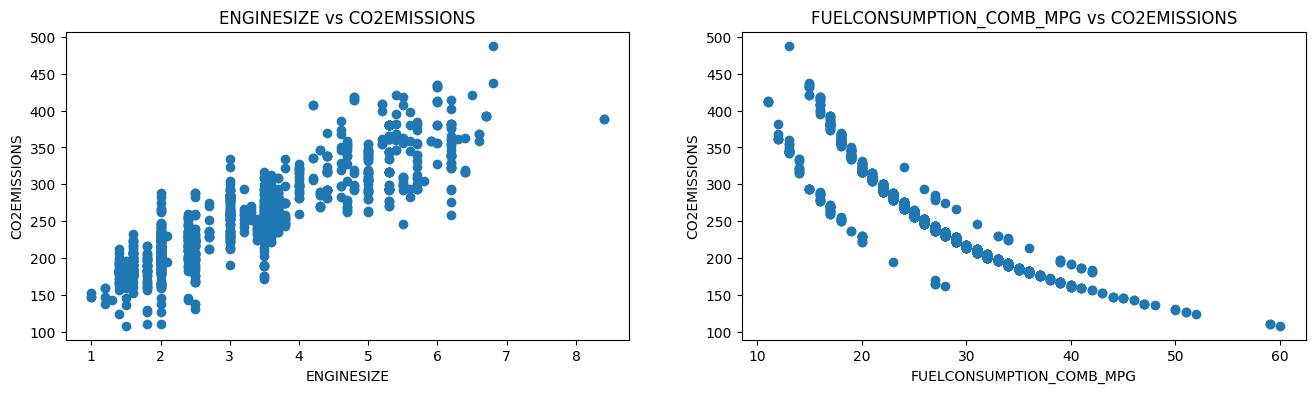

In [66]:
x=features[['ENGINESIZE','FUELCONSUMPTION_COMB_MPG']].columns
target='CO2EMISSIONS'
fig, axes = plt.subplots(1,2,figsize=(16,4))
for ax,x in zip(axes,x):
    ax.scatter(x=x, y=target, data=features)
    ax.set_xlabel(x)
    ax.set_ylabel(target)
    ax.set_title(f"{x} vs {target}")

Non Linear Relationship b/w CO2 Emissions ad Fuel Consumptions in MPG. We can reciprocate it

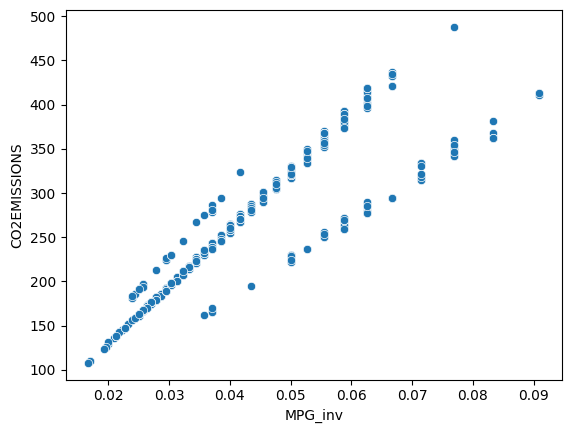

In [69]:
features['MPG_inv'] = 1 / features['FUELCONSUMPTION_COMB_MPG']
sns.scatterplot(x='MPG_inv', y='CO2EMISSIONS', data=features)
plt.show()

In [72]:
target = features['CO2EMISSIONS']
features.drop(columns=['FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'], inplace=True)
print(features.columns)

Index(['ENGINESIZE', 'MPG_inv'], dtype='str')


Since MPG inverse is in decimals so we should scale it to match with other feature, in LR we dont really need scaling but good habit

In [74]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features,target,test_size=0.3,random_state=42)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [75]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)
print('Cofficient = ', model.coef_[0])
print('Intercept = ', model.intercept_)

Cofficient =  19.549679420735274
Intercept =  80.51553584308652


In [77]:
y_pred = model.predict(x_test)

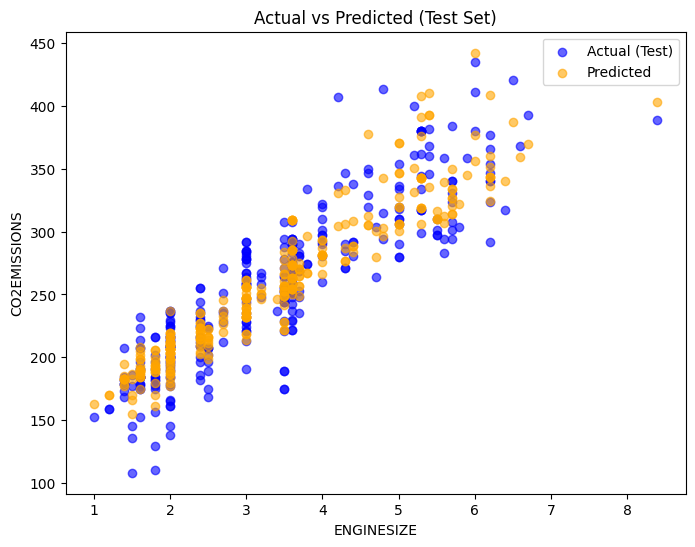

In [80]:
plt.figure(figsize=(8,6))
plt.scatter(x_test['ENGINESIZE'], y_test, color='blue', alpha=0.6, label='Actual (Test)')
plt.scatter(x_test['ENGINESIZE'], y_pred, color='orange', alpha=0.6, label='Predicted')
plt.xlabel('ENGINESIZE')
plt.ylabel('CO2EMISSIONS')
plt.title('Actual vs Predicted (Test Set)')
plt.legend()
plt.show()

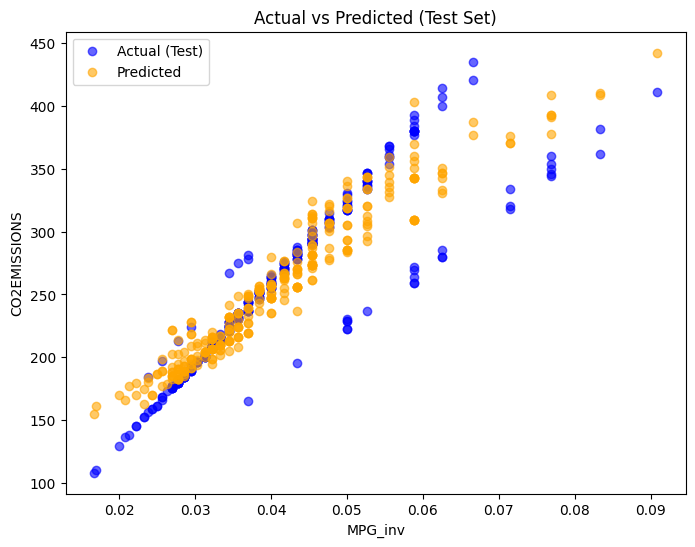

In [82]:
plt.figure(figsize=(8,6))
plt.scatter(x_test['MPG_inv'], y_test, color='blue', alpha=0.6, label='Actual (Test)')
plt.scatter(x_test['MPG_inv'], y_pred, color='orange', alpha=0.6, label='Predicted')
plt.xlabel('MPG_inv')
plt.ylabel('CO2EMISSIONS')
plt.title('Actual vs Predicted (Test Set)')
plt.legend()
plt.show()